# Exercice 1 - Découvrez les blocs de construction de l'Apprentissage par Renforcement

**Objectif :** Se familiariser avec le cycle fondamental "observation -> action -> récompense"

Dans cet exercice, nous allons :
1. Créer un environnement CartPole-v1
2. Explorer ses espaces d'observation et d'action
3. Implémenter une boucle d'interaction agent-environnement sur 10 épisodes

## 1. Import des bibliothèques

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

## 2. Partie 1 : Exploration de l'environnement

### Création de l'environnement CartPole-v1

In [3]:
# Créer l'environnement
env = gym.make("CartPole-v1")
print(f"Environnement créé : {env}")
print(f"Horizon (max steps) : {env.spec.max_episode_steps}")

Environnement créé : <TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>
Horizon (max steps) : 500


### Espace d'observation

L'espace d'observation décrit ce que l'agent "voit" (état du système).

In [4]:
print("=== Espace d'observation ===")
print(f"Type : {env.observation_space}")
print(f"Description : {env.observation_space.dtype}")
print(f"Bornes basses : {env.observation_space.low}")
print(f"Bornes hautes : {env.observation_space.high}")

# Exemple d'observation aléatoire
print(f"\nExemple d'observation : {env.observation_space.sample()}")

=== Espace d'observation ===
Type : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Description : float32
Bornes basses : [-4.8               -inf -0.41887903        -inf]
Bornes hautes : [4.8               inf 0.41887903        inf]

Exemple d'observation : [-2.508061  -1.7823992 -0.17445    1.6108682]


**Interprétation :**
- `Box(4,)` = 4 valeurs continues
- `x` = position du chariot
- `x_dot` = vitesse du chariot
- `theta` = angle du pendule
- `theta_dot` = vitesse angulaire

### Espace d'action

L'espace d'action décrit ce que l'agent "peut faire".

In [5]:
print("=== Espace d'action ===")
print(f"Type : {env.action_space}")

# Exemple d'actions aléatoires
actions = [env.action_space.sample() for _ in range(10)]
print(f"Exemples d'actions (aléatoires) : {actions}")
print(f"\nInterprétation :")
print(f"  - 0 = Pousser à gauche")
print(f"  - 1 = Pousser à droite")

=== Espace d'action ===
Type : Discrete(2)
Exemples d'actions (aléatoires) : [np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]

Interprétation :
  - 0 = Pousser à gauche
  - 1 = Pousser à droite


## 3. Partie 2 : Boucle d'interaction agent-environnement

Nous allons maintenant exécuter 10 épisodes avec un agent aléatoire.

In [6]:
# Réinitialiser l'environnement
observation, info = env.reset()
print(f"État initial : {observation}")

État initial : [-0.02135037 -0.04189973  0.01773604  0.03581405]


In [7]:
# Exécuter UN episode complet
total_reward = 0
terminated = truncated = False
steps = 0

while not (terminated or truncated):
    # 1. Choisir une action aléatoire
    action = env.action_space.sample()
    
    # 2. Exécuter l'action
    observation, reward, terminated, truncated, info = env.step(action)
    
    # 3. Accumuler la récompense
    total_reward += reward
    steps += 1

print(f"Épisode terminé !")
print(f"  - Steps : {steps}")
print(f"  - Reward total : {total_reward}")

Épisode terminé !
  - Steps : 26
  - Reward total : 26.0


In [8]:
# Boucle sur 10 épisodes
n_episodes = 10
rewards_per_episode = []

for episode in range(n_episodes):
    # Réinitialiser l'environnement pour chaque épisode
    observation, info = env.reset()
    
    total_reward = 0
    terminated = truncated = False
    
    while not (terminated or truncated):
        action = env.action_space.sample()  # Action aléatoire
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
    
    rewards_per_episode.append(total_reward)
    print(f"Épisode {episode+1}/{n_episodes}: {total_reward} points")

# Fermer l'environnement
env.close()

Épisode 1/10: 11.0 points
Épisode 2/10: 26.0 points
Épisode 3/10: 32.0 points
Épisode 4/10: 15.0 points
Épisode 5/10: 16.0 points
Épisode 6/10: 15.0 points
Épisode 7/10: 15.0 points
Épisode 8/10: 10.0 points
Épisode 9/10: 13.0 points
Épisode 10/10: 21.0 points


## 4. Visualisation des résultats

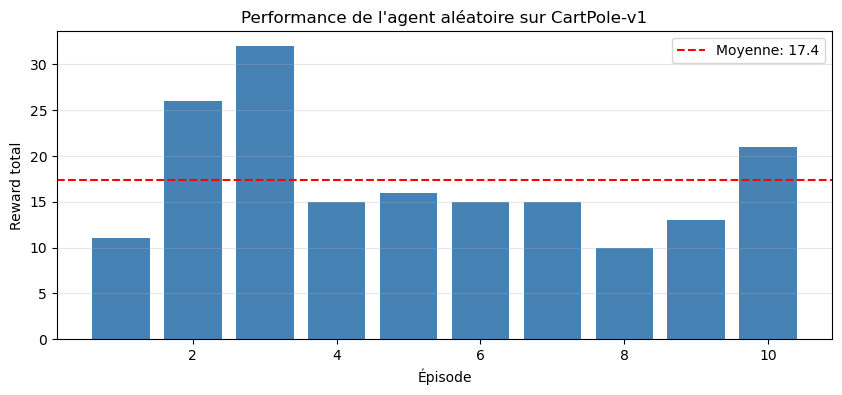


=== Résumé ===
Reward moyen : 17.4
Reward max : 32.0
Reward min : 10.0


In [9]:
plt.figure(figsize=(10, 4))
plt.bar(range(1, n_episodes + 1), rewards_per_episode, color='steelblue')
plt.axhline(y=np.mean(rewards_per_episode), color='red', linestyle='--', label=f'Moyenne: {np.mean(rewards_per_episode):.1f}')
plt.xlabel('Épisode')
plt.ylabel('Reward total')
plt.title('Performance de l\'agent aléatoire sur CartPole-v1')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"\n=== Résumé ===")
print(f"Reward moyen : {np.mean(rewards_per_episode):.1f}")
print(f"Reward max : {np.max(rewards_per_episode)}")
print(f"Reward min : {np.min(rewards_per_episode)}")

## Conclusion

**Observations clés :**
- L'agent aléatoire obtient en moyenne ~20-50 points (score faible)
- CartPole-v1 termine quand `theta` dépasse ±15° ou `x` sort des limites
- Le score maximum théorique est 500 (25s × 20 steps/s)

**Prochaines étapes :**
- Entraîner un agent intelligent avec Q-Learning (Exercice 2)
- Puis un agent avec réseau de neurones (Exercice 3)